데이터 확인
   study_hours      score
0     4.370861  35.402124
1     9.556429  74.956393
2     7.587945  61.162368
3     6.387926  41.165566
4     2.404168  18.134983
데이터 크기:(100, 2)
학습 데이터:80개
테스트 데이터:20개
학습 완료
기울기:7.78
절편:0.94
모델 평가
MSE:16.34
R2 score:0.9659


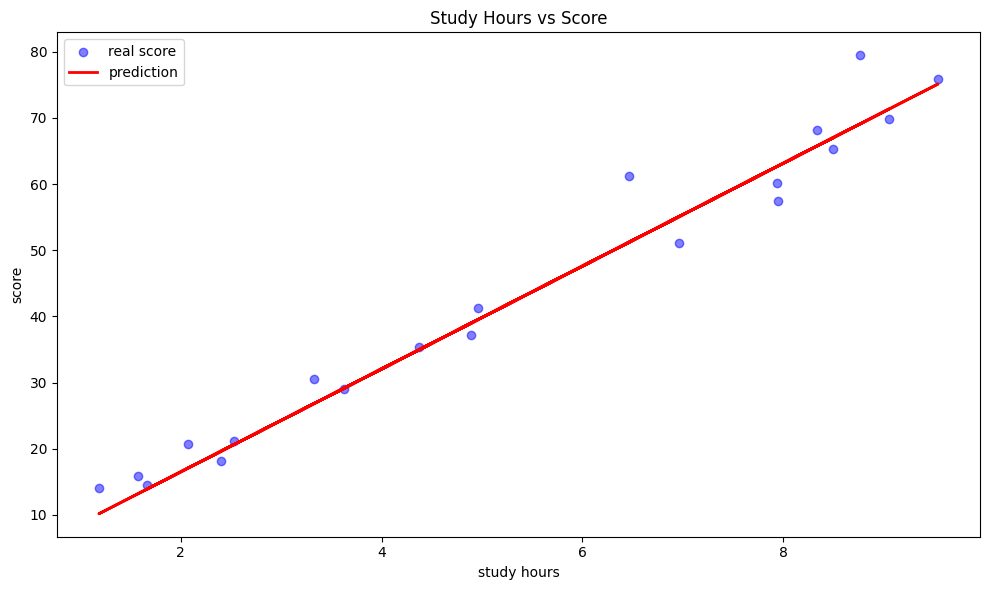

5시간 공부했을 때 예상 점수:39.8점


c:\Users\seoks\ai_class\streamlit_labs_2222\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 예제 데이터 만들기
study_hours = np.random.uniform(1, 10, 100)
scores = study_hours * 8 + np.random.normal(0, 5, 100)

df = pd.DataFrame({
    "study_hours": study_hours,
    "score": scores,
})

print("데이터 확인")
print(df.head())
print(f"데이터 크기:{df.shape}")

# Feature와 Label 분리
X = df[["study_hours"]]
y = df["score"]

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"학습 데이터:{X_train.shape[0]}개")
print(f"테스트 데이터:{X_test.shape[0]}개")

# 모델 선택과 학습
model = LinearRegression()
model.fit(X_train, y_train)

print("학습 완료")
print(f"기울기:{model.coef_[0]:.2f}")
print(f"절편:{model.intercept_:.2f}")

# 예측
y_pred = model.predict(X_test)

# 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("모델 평가")
print(f"MSE:{mse:.2f}")
print(f"R2 score:{r2:.4f}")

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="real score")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="prediction")
plt.xlabel("study hours")
plt.ylabel("score")
plt.title("Study Hours vs Score")
plt.legend()
plt.tight_layout()
plt.savefig("result.png")
plt.show()

# 새 데이터 예측
new_data = np.array([[5]])
predicted_score = model.predict(new_data)
print(f"5시간 공부했을 때 예상 점수:{predicted_score[0]:.1f}점")

In [2]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:{mse:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"MAE:{mae:.2f}")
print(f"R2:{r2:.4f}")

MSE:16.34
RMSE:4.04
MAE:2.96
R2:0.9659


In [3]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

ValueError: continuous is not supported

In [4]:
# 1. 모델 가져오기
from sklearn.모듈 import 모델이름

# 2. 모델 만들기
model = 모델이름()

# 3. 학습
model.fit(X_train, y_train)

# 4. 예측
y_pred = model.predict(X_test)

# 5. 평가
score = model.score(X_test, y_test)

ModuleNotFoundError: No module named 'sklearn.모듈'

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [6]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
)
model.fit(X_train, y_train)

print(f"정확도:{model.score(X_test, y_test):.4f}")

importance = pd.Series(
    model.feature_importances_,
    index=iris.feature_names,
).sort_values(ascending=False)

print("특성 중요도")
print(importance)

정확도:0.9667
특성 중요도
petal length (cm)    0.579077
petal width (cm)     0.420923
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


In [7]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)
model.fit(X_train, y_train)

print(f"정확도:{model.score(X_test, y_test):.4f}")

정확도:0.9333


In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

print(f"정확도:{model.score(X_test_scaled, y_test):.4f}")

정확도:0.9333


In [9]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)
model.fit(X_train_scaled, y_train)

print(f"정확도:{model.score(X_test_scaled, y_test):.4f}")

proba = model.predict_proba(X_test_scaled[:3])
print("예측 확률")
print(proba)

정확도:0.9333
예측 확률
[[9.78818005e-01 2.11816311e-02 3.63821812e-07]
 [3.79836951e-03 3.69220168e-01 6.26981463e-01]
 [1.48799040e-01 8.42474895e-01 8.72606441e-03]]


In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.random.uniform(1, 10, size=(100, 1))
y = X.ravel() * 8 + np.random.normal(0, 5, 100)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R2 score:{r2_score(y_test, y_pred):.4f}")
print(f"기울기:{model.coef_[0]:.2f}")
print(f"절편:{model.intercept_:.2f}")

R2 score:0.9659
기울기:7.78
절편:0.94


In [11]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.random.uniform(1, 10, size=(100, 1))
y = X.ravel() * 8 + np.random.normal(0, 5, 100)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R2 score:{r2_score(y_test, y_pred):.4f}")

R2 score:0.9612


In [12]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append({"model": name, "accuracy": acc})
    print(f"{name}:{acc:.4f}")

result_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)

print("모델 비교 결과")
print(result_df.to_string(index=False))

Logistic Regression:0.9825
Decision Tree:0.9123
Random Forest:0.9561
KNN:0.9561
모델 비교 결과
              model  accuracy
Logistic Regression  0.982456
      Random Forest  0.956140
                KNN  0.956140
      Decision Tree  0.912281


In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42)),
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(f"정확도:{accuracy_score(y_test, y_pred):.4f}")

정확도:0.9561


데이터 크기: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
결측치
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_m

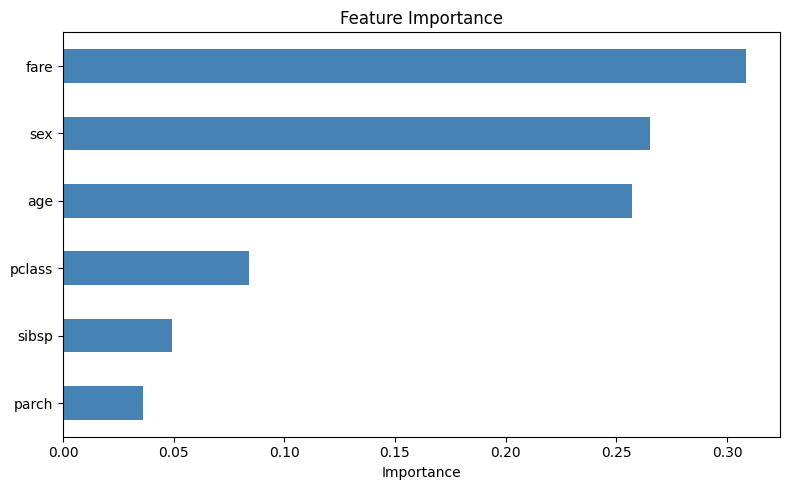

새 승객 예측:사망
생존 확률:0.0%


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

df = sns.load_dataset("titanic")

print("데이터 크기:", df.shape)
print(df.head())

print("결측치")
print(df.isnull().sum())

print("생존 비율")
print(df["survived"].value_counts(normalize=True))

features = ["pclass", "sex", "age", "sibsp", "parch", "fare"]
df_model = df[features + ["survived"]].copy()

# 결측치 처리
df_model["age"] = df_model["age"].fillna(df_model["age"].median())
df_model["fare"] = df_model["fare"].fillna(df_model["fare"].median())

# 문자 데이터를 숫자로 변환
df_model["sex"] = df_model["sex"].map({"male": 0, "female": 1})

X = df_model[features]
y = df_model["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"정확도:{accuracy_score(y_test, y_pred):.4f}")
print("분류 리포트")
print(classification_report(y_test, y_pred, target_names=["사망", "생존"]))

importance = pd.Series(
    model.feature_importances_,
    index=features,
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("titanic_importance.png")
plt.show()

new_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": [0],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.5],
})

prediction = model.predict(new_passenger)
proba = model.predict_proba(new_passenger)

result = "생존" if prediction[0] == 1 else "사망"

print(f"새 승객 예측:{result}")
print(f"생존 확률:{proba[0][1]:.1%}")